In [2]:
import pandas as pd

df = pd.read_csv("data/TESS.csv", comment="#")
print(df['tfopwg_disp'].value_counts())



df.head()

tfopwg_disp
PC     4772
FP     1235
CP      714
KP      589
APC     480
FA      100
Name: count, dtype: int64


,rowid,toi,toipfx,tid,ctoi_alias,pl_pnum,tfopwg_disp,rastr,ra,raerr1,...,st_loggerr2,st_logglim,st_loggsymerr,st_rad,st_raderr1,st_raderr2,st_radlim,st_radsymerr,toi_created,rowupdate
0,1,1000.01,1000,50365310,5.036531e+07,1,FP,07h29m25.85s,112.357708,NaN,...,-0.07,0,1,2.16986,0.072573,-0.072573,0,1,2019-07-24 15:58:33,2024-09-09 10:08:01
1,2,1001.01,1001,88863718,8.886372e+07,1,PC,08h10m19.31s,122.580465,NaN,...,-0.09,0,1,2.01000,0.090000,-0.090000,0,1,2019-07-24 15:58:33,2023-04-03 14:31:04
2,3,1002.01,1002,124709665,1.247097e+08,1,FP,06h58m54.47s,104.726966,NaN,...,NaN,0,1,5.73000,NaN,NaN,0,1,2019-07-24 15:58:33,2022-07-11 16:02:02
3,4,1003.01,1003,106997505,1.069975e+08,1,FP,07h22m14.39s,110.559945,NaN,...,-1.64,0,1,NaN,NaN,NaN,0,1,2019-07-24 15:58:33,2022-02-23 10:10:02
4,5,1004.01,1004,238597883,2.385979e+08,1,FP,08h08m42.77s,122.178195,NaN,...,-0.07,0,1,2.15000,0.060000,-0.060000,0,1,2019-07-24 15:58:33,2024-09-09 10:08:01


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7890 entries, 0 to 7889
Data columns (total 87 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              7890 non-null   int64  
 1   toi                7890 non-null   float64
 2   toipfx             7890 non-null   int64  
 3   tid                7890 non-null   int64  
 4   ctoi_alias         7890 non-null   float64
 5   pl_pnum            7890 non-null   int64  
 6   tfopwg_disp        7890 non-null   object 
 7   rastr              7890 non-null   object 
 8   ra                 7890 non-null   float64
 9   raerr1             0 non-null      float64
 10  raerr2             0 non-null      float64
 11  decstr             7890 non-null   object 
 12  dec                7890 non-null   float64
 13  decerr1            0 non-null      float64
 14  decerr2            0 non-null      float64
 15  st_pmra            7756 non-null   float64
 16  st_pmraerr1        7756 

In [3]:
print([col for col in df.columns if 'snr' in col.lower() or 'noise' in col.lower()])

[]


In [4]:
tess_goldilock_query = (
    "tfopwg_disp in ['CP', 'KP', 'APC'] and "
    "0.5 <= pl_rade <= 2.0 and "
    "200 <= pl_eqt <= 320"
)

earth_like = df.query(tess_goldilock_query)
viev = earth_like[['toipfx', 'tid', 'tfopwg_disp', 'pl_orbper', 'pl_rade', 'pl_eqt', 'st_teff', 'st_rad']]
print(f"From {len(df)} TESS data earth like planet count: {len(earth_like)}")
print(viev.to_markdown())

From 7890 TESS data earth like planet count: 10
|      |   toipfx |       tid | tfopwg_disp   |   pl_orbper |   pl_rade |   pl_eqt |   st_teff |   st_rad |
|-----:|---------:|----------:|:--------------|------------:|----------:|---------:|----------:|---------:|
|  538 |     1452 | 420112589 | CP            |    11.062   |  1.61849  |  304.153 |      3248 | 0.275364 |
| 1306 |     2095 | 235678745 | CP            |    28.1723  |  1.44752  |  300.658 |      3746 | 0.463205 |
| 1534 |     2285 | 329148988 | CP            |    27.2672  |  1.57811  |  287.077 |      3546 | 0.460014 |
| 5407 |     5713 | 219041246 | CP            |    10.442   |  1.86055  |  317.815 |      3271 | 0.292425 |
| 5730 |     6002 | 102734241 | CP            |    10.9048  |  1.54895  |  296.397 |      3272 | 0.242121 |
| 6009 |     6251 |  52005579 | CP            |    12.7615  |  0.970576 |  299.507 |      3376 | 0.269427 |
| 6532 |     6714 | 261264800 | APC           |     4.76744 |  1.03651  |  275.068 |    

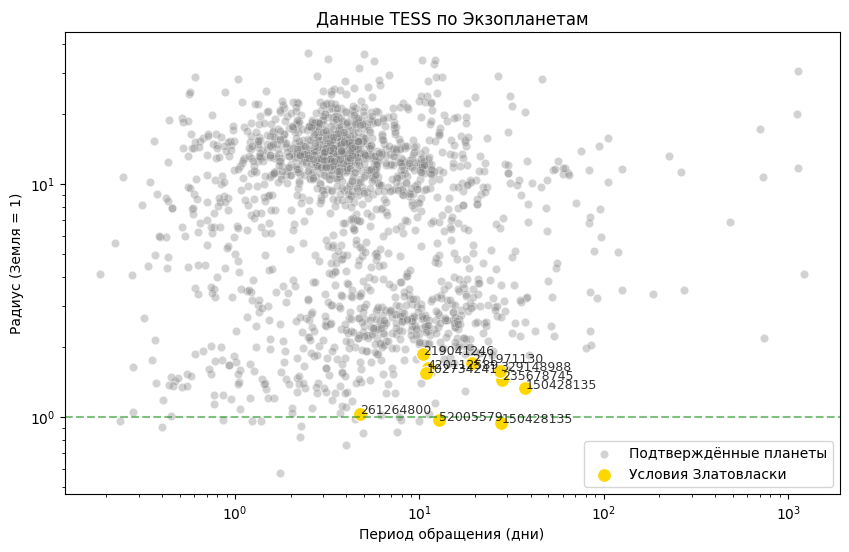

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

tess_planet_query = ("tfopwg_disp in ['CP', 'KP', 'APC']")
planet_query = df.query(tess_planet_query)

#All confirmed and strong candidates
sns.scatterplot(data=planet_query, #data=df[df['tfopwg_disp'].isin(['CP', 'KP', 'APC'])
                x='pl_orbper', y='pl_rade', color='gray', alpha=0.35, label='Подтверждённые планеты')

#TESS "goldilock zone"
sns.scatterplot(data=earth_like,
                x='pl_orbper', y='pl_rade', color='gold', s=100, label='Условия Златовласки')

plt.xscale('log')
plt.yscale('log')
plt.axhline(1, color='green', linestyle='--', alpha=0.5)
plt.title('Данные TESS по Экзопланетам')
plt.xlabel('Период обращения (дни)')
plt.ylabel('Радиус (Земля = 1)')
plt.legend()

for orbper, rade, name in zip(earth_like['pl_orbper'],
                              earth_like['pl_rade'],
                              earth_like['tid']):
    plt.text(
        x=orbper,
        y=rade,
        s=str(name),
        fontsize=9,
        color='black',
        alpha=0.8,
        )
plt.show()
